# Student Performance Prediction using Linear Regression

## Machine Learning Assignment

### Objective
The objective of this project is to predict students' Exam_Score using Machine Learning Linear Regression algorithm.

### Dataset
Student Performance Dataset

### Target Variable
Exam_Score

### Machine Learning Algorithm
Linear Regression

### Project Workflow
1. Data Loading
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Model Training
6. Prediction
7. Model Evaluation

In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## 1. Loading Dataset

In this step, we will load the Student Performance dataset using pandas and check the basic structure of the data.

In [5]:
# Load Dataset from Downloads folder

df = pd.read_csv(r"C:\Users\User\Downloads\student_habits_performance.csv")

# Display first 5 rows

df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 2. Dataset Overview

In this section, we will explore the basic structure of the dataset, including the number of rows, columns, data types, and statistical information.

In [6]:
# Check Dataset Shape

print("Number of Rows and Columns:")
df.shape

Number of Rows and Columns:


(1000, 16)

In [8]:
# Display Column Names

df.columns


Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [10]:
# Statistical Summary

df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


## 3. Data Cleaning and Preprocessing

In this step, we will check missing values, duplicate records, and prepare the dataset for machine learning.

In [11]:
# Check Missing Values

df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [12]:
# Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [13]:
# Dataset Size After Checking

df.shape

(1000, 16)

In [14]:
# Select Numeric Columns

numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the patterns, relationships, and distribution of data using statistical methods and visualizations.

In [15]:
# Display Dataset Columns

df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

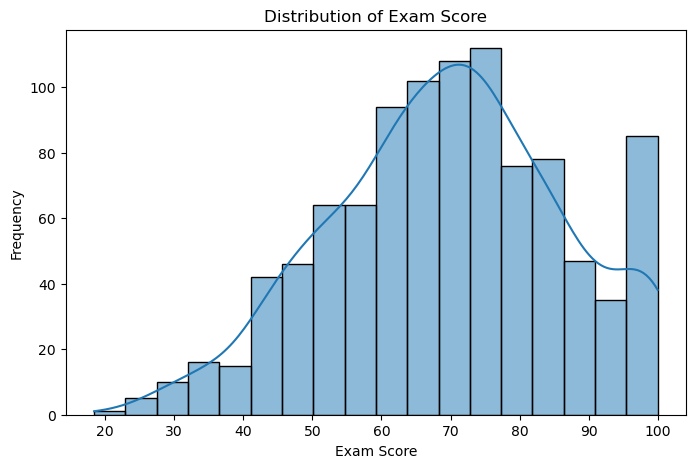

In [18]:
# Distribution of Exam Score

plt.figure(figsize=(8,5))

sns.histplot(df['exam_score'], kde=True)

plt.title("Distribution of Exam Score")

plt.xlabel("Exam Score")

plt.ylabel("Frequency")

plt.show()

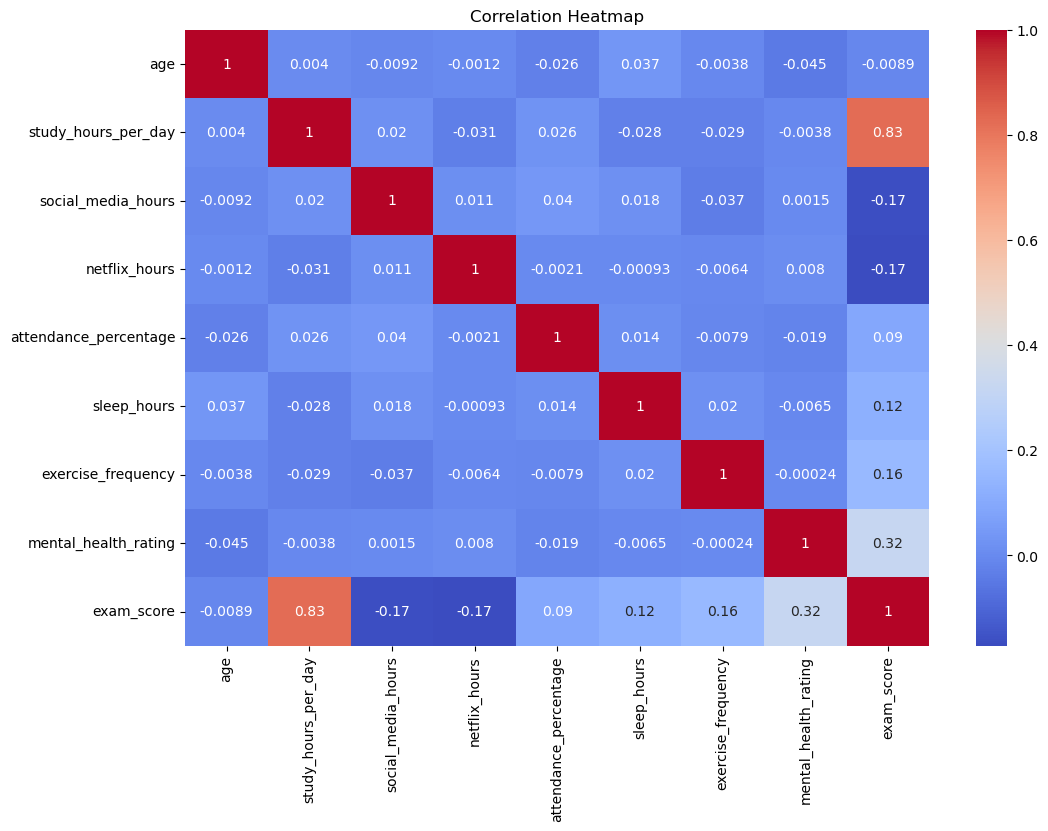

In [19]:
# Correlation Matrix

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## 5. Feature Selection

In this step, we will select numerical features from the dataset and separate the target variable (exam_score) for training the Linear Regression model.

In [20]:
# Select Numeric Features

numeric_features = df.select_dtypes(include=np.number).columns

numeric_features

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [21]:
# Define Features and Target

X = df[numeric_features].drop('exam_score', axis=1)

y = df['exam_score']


print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (1000, 8)
Target Shape: (1000,)


## 6. Train-Test Split

The dataset is divided into training and testing data. The training data is used to train the model, while testing data is used to evaluate model performance.

In [24]:
# Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (800, 8)
Testing Data: (200, 8)


## 7. Building Linear Regression Model

In this step, we will train a Linear Regression model using the training dataset to predict students' exam scores.

In [25]:
# Create Linear Regression Model

model = LinearRegression()

print("Linear Regression Model Created Successfully!")

Linear Regression Model Created Successfully!


In [26]:
# Train the Model

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


## 8. Making Predictions

The trained model will be used to predict exam scores on the testing dataset.

In [27]:
# Predict Exam Scores

y_pred = model.predict(X_test)

# Display First 10 Predictions

y_pred[:10]

array([66.05204297, 74.48132707, 78.10484796, 74.38034364, 61.42454555,
       54.83488838, 75.91771188, 55.42801281, 41.61008609, 72.81612496])

## 9. Model Evaluation

The performance of the Linear Regression model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [28]:
# Calculate Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


# Display Results

print("Model Performance:")

print("-------------------------")

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R² Score:", r2)

Model Performance:
-------------------------
Mean Absolute Error (MAE): 4.130186149064832
Mean Squared Error (MSE): 25.921009909012604
Root Mean Squared Error (RMSE): 5.091268006009171
R² Score: 0.8989154884786842


## 10. Actual vs Predicted Values

The following visualization compares the actual exam scores with the predicted scores generated by the Linear Regression model.

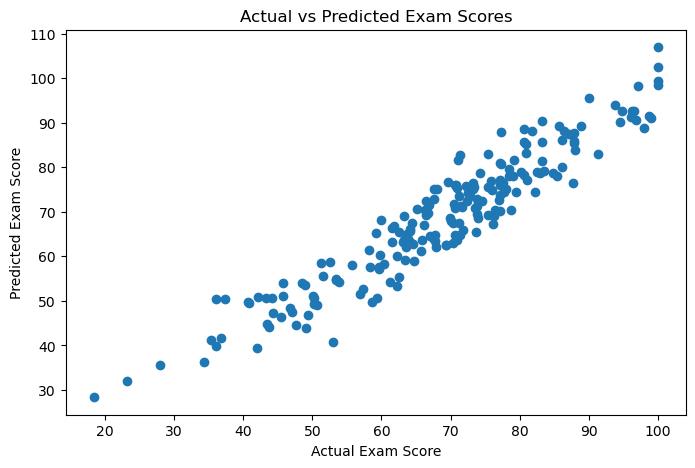

In [30]:
# Actual vs Predicted Visualization

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")

plt.ylabel("Predicted Exam Score")

plt.title("Actual vs Predicted Exam Scores")

plt.show()

## 11. Conclusion

In this project, a Linear Regression model was developed to predict students' exam scores using the Student Performance Dataset.

The dataset was preprocessed, numerical features were selected, and the model was trained successfully.

Model performance was evaluated using MAE, MSE, RMSE, and R² Score.

The results show how machine learning can be used to predict student performance based on different academic and lifestyle factors.